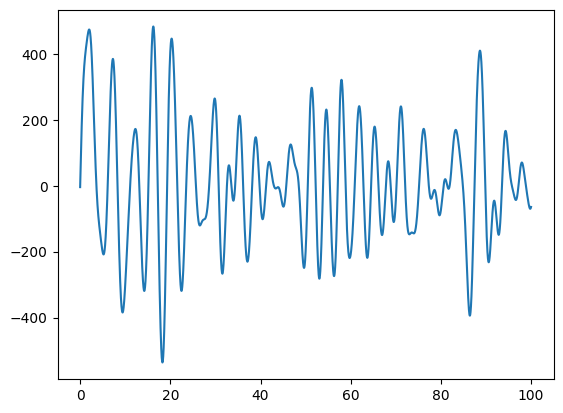

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal


data = np.loadtxt("notebook/data/itmx_z_1441947618.txt")
data_dt = 1/512  # Data sampling rate
dt = 1/64  # Downsampled rate
q = int(dt/data_dt)  # Downsampling factor

y = scipy.signal.decimate(data, q)
y = y-np.mean(y)

t = np.arange(0, dt*len(y), dt)

fs = 1/dt  # Sampling frequency in Hz
lowcut = 0.05 # Low cutoff frequency in Hz
highcut = 0.5 # High cutoff frequency in Hz
N = 4 # Filter order

sos = scipy.signal.butter(N, (lowcut, highcut), btype='bandpass', fs=fs, output='sos')

y_ = scipy.signal.sosfiltfilt(sos, y)  # Down sampled

# np.savetxt(t, )
# f, pyy = scipy.signal.welch(y, fs=1/dt, nperseg=int(len(y)/10))
# f, pyy_ = scipy.signal.welch(y_, fs=1/dt, nperseg=int(len(y_)/10))

# ayy = pyy**.5
# ayy_ = pyy_**.5

# plt.loglog(f, ayy)
# plt.loglog(f, ayy_)

# plt.plot(t[0:6400], y[0:6400])
plt.plot(t[0:6400], y_[0:6400])

In [22]:
import seisim.predictor
import seisim.controller

n_predict = int(1/dt)  # 1 second
n_control = int(0.5/dt) # 0.5 seconds

predictor = seisim.predictor.ConstantOrder(
    dt=dt, order=7, n_forecast=n_predict)

controller = seisim.controller.MPCFF(
    model=None, n_predict=n_predict, n_control=n_control, predictor=predictor)

In [23]:
y_act = y[:6400]
y_sim = y_[:6400]
t_sim = t[:6400]

residual = np.zeros_like(y_sim)
for i in range(predictor.n_history, len(t_sim), n_control):
    seismic = y_sim[i-predictor.n_history:i]
    actuation = controller.run(seismic)
    if len(residual[i:i+n_control]) < n_control:
        remain = len(residual[i:i+n_control])
#         print(remain)
        residual[i:i+remain] = y_act[-remain:] + actuation[:remain]
    else:
        residual[i:i+n_control] = y_act[i:i+n_control] + actuation
    
    

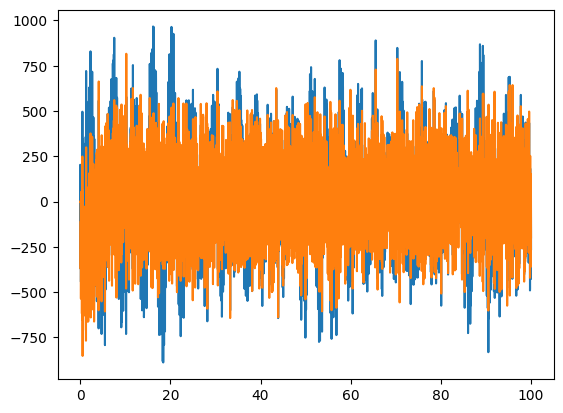

In [24]:
plt.plot(t_sim, y_act)
plt.plot(t_sim, residual)

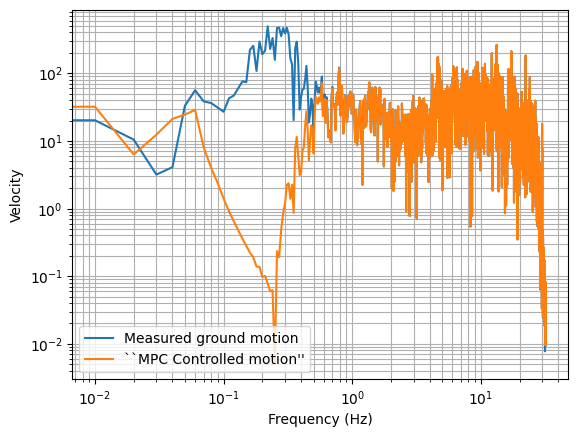

In [25]:
f, pyy = scipy.signal.welch(y_act, fs=1/dt, nperseg=int(len(y_act)))
f, pyy_ = scipy.signal.welch(residual, fs=1/dt, nperseg=int(len(residual)))

ayy = pyy**.5
ayy_ = pyy_**.5


plt.loglog(f, ayy, label="Measured ground motion")
plt.loglog(f, ayy_, label="``MPC Controlled motion''")

plt.ylabel("Velocity")
plt.xlabel("Frequency (Hz)")
plt.grid(which="both")
plt.legend(loc=0)

In [26]:
n_control

32

In [16]:
y_sim[5-3:5]

array([13.70348038, 22.68144337, 31.62364435])

In [3]:
predictor.n_history

3

In [ ]:
y_[]

In [6]:
actuation = controller.run(y_[:predictor.n_history+1])

In [7]:
actuation

array([-302.40228066, -310.37709569, -318.32240636, -326.23821268,
       -334.12451465, -341.98131227, -349.80860554, -357.60639445,
       -365.37467902, -373.11345923, -380.82273509, -388.5025066 ,
       -396.15277375, -403.77353656, -411.36479501, -418.92654911,
       -426.45879885, -433.96154425, -441.4347853 , -448.87852199,
       -456.29275433, -463.67748232, -471.03270595, -478.35842524,
       -485.65464017, -492.92135075, -500.15855698, -507.36625886,
       -514.54445638, -521.69314956, -528.81233838, -535.90202285])

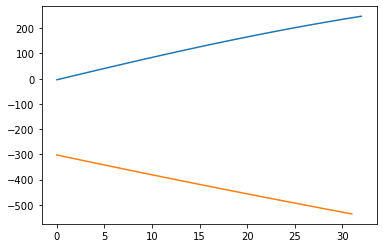

In [8]:
plt.plot(y_[n_pre:n_control+1])
plt.plot(actuation)